# Statistical analysis of the three segmentation models

Are the differences between U-Net, nnU-Net and DeepLabV3+ on the 130 BUSI test images
real, or could they be noise? Inputs are the three `per_image_metrics.csv` files from
Task 6 (Dice, IoU, HD95 per test image, same image order). Steps:

1. mean ± standard deviation of every metric,
2. pairwise **paired t-tests** (`scipy.stats.ttest_rel`) with **Holm correction**
   (`statsmodels multipletests, method="holm"`),
3. the same comparisons with the **Wilcoxon signed-rank test** as a non-parametric check,
4. one results table with raw p-values, Holm-adjusted p-values and significance at α = 0.05.

## 1. Configuration

Model folders, metric names and the significance level.

In [1]:
import os

# The three Task 6 models: folder, display name, colour (same colours as in Task 6)
MODELS = {
    "unet":          {"dir": "../task6_unet",          "label": "U-Net",      "color": "#2a78d6"},
    "nnunet":        {"dir": "../task6_nnunet",        "label": "nnU-Net",    "color": "#eb6834"},
    "deeplabv3plus": {"dir": "../task6_deeplabv3plus", "label": "DeepLabV3+", "color": "#1baf7a"},
}
METRICS = ["dice", "iou", "hd95"]

METRIC_LABELS = {"dice": "Dice", "iou": "IoU", "hd95": "HD95 (px)"}
HIGHER_IS_BETTER = {"dice": True, "iou": True, "hd95": False}
ALPHA = 0.05              # significance level after Holm correction
OUT_DIR = "."             # result tables are written next to this notebook

## 2. Imports

In [2]:
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

## 3. Load the per-image metrics

Paired tests compare the two models **on the same image**, so the rows of the three files
must refer to the same images in the same order — we assert it rather than assume it.

In [3]:
dfs = {k: pd.read_csv(os.path.join(v["dir"], "per_image_metrics.csv")) for k, v in MODELS.items()}
ref = dfs["unet"]["image_name"].tolist()
for k, d in dfs.items():
    assert list(d.columns) == ["image_name"] + METRICS, f"{k}: unexpected columns {list(d.columns)}"
    assert d["image_name"].tolist() == ref, f"{k}: image order differs"
    assert not d[METRICS].isna().any().any(), f"{k}: missing values"
N = len(ref)
print(f"{N} paired test images for {len(MODELS)} models")

130 paired test images for 3 models


## 4. Mean ± standard deviation

- **Mean** — the average of a metric over the 130 test images: the model's typical score.
- **Standard deviation (SD)** — how much the per-image scores spread around that mean
  (sample SD, `ddof=1`). A large SD means the model is good on some images and bad on
  others; it describes the images, **not** how precisely the mean is known.

Because we have one score per test image, a model with mean Dice 0.80 ± 0.20 can still be
much worse than another on many individual images — which is why the comparisons below
use the per-image pairs, not just the two means. The median is shown too, because HD95 is
strongly right-skewed (a few images with very large boundary errors pull the mean up).

In [4]:
desc_rows = []
for k, v in MODELS.items():
    row = {"model": v["label"]}
    for m in METRICS:
        x = dfs[k][m]
        row[METRIC_LABELS[m]] = f"{x.mean():.4f} ± {x.std(ddof=1):.4f}" if m != "hd95" else f"{x.mean():.2f} ± {x.std(ddof=1):.2f}"
        row[f"{METRIC_LABELS[m]} median"] = round(x.median(), 4 if m != "hd95" else 2)
    desc_rows.append(row)
desc = pd.DataFrame(desc_rows).set_index("model")
desc.to_csv(os.path.join(OUT_DIR, "descriptive_stats.csv"))
desc

,Dice,Dice median,IoU,IoU median,HD95 (px),HD95 (px) median
model,,,,,,
U-Net,0.7301 ± 0.3108,0.8862,0.6491 ± 0.3093,0.7956,104.01 ± 162.88,37.01
nnU-Net,0.7797 ± 0.2388,0.8898,0.6874 ± 0.2530,0.8015,70.78 ± 114.18,25.34
DeepLabV3+,0.7971 ± 0.2594,0.9060,0.7185 ± 0.2642,0.8281,64.31 ± 90.41,18.11


## 5. Distribution of the per-image scores

Box plots (median, quartiles, 1.5×IQR whiskers) with every test image as a dot. Wide
boxes and long tails show what the SD summarises.

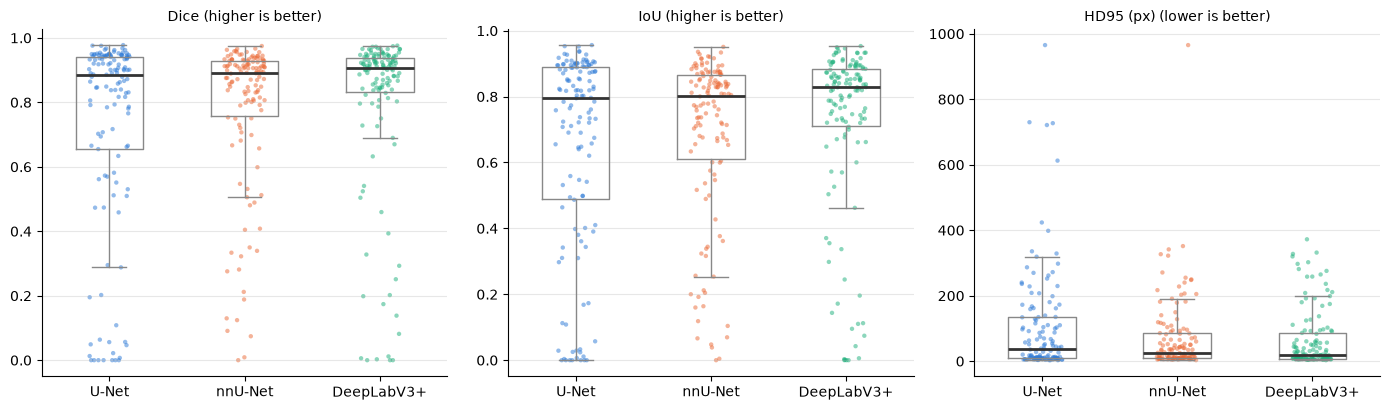

In [5]:
rng = np.random.default_rng(0)   # jitter only, for display
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, m in zip(axes, METRICS):
    data = [dfs[k][m].values for k in MODELS]
    ax.boxplot(data, widths=0.5, showfliers=False,
               medianprops={"color": "#333333", "linewidth": 2},
               boxprops={"color": "#888888"}, whiskerprops={"color": "#888888"}, capprops={"color": "#888888"})
    for i, (k, v) in enumerate(MODELS.items(), start=1):
        ax.scatter(i + rng.uniform(-0.15, 0.15, N), dfs[k][m], s=10, alpha=0.5, color=v["color"],
                   edgecolors="none")
    ax.set_xticks(range(1, len(MODELS) + 1), [v["label"] for v in MODELS.values()])
    ax.set_title(METRIC_LABELS[m] + (" (higher is better)" if HIGHER_IS_BETTER[m] else " (lower is better)"),
                 fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "metric_distributions.png"), dpi=120)
plt.show()

## 6. Paired t-test

**Question**: for two models A and B, is the average of the per-image differences
dᵢ = scoreᴬᵢ − scoreᴮᵢ different from 0?

- *Paired* because both models were evaluated on the **same** 130 images. Some images are
  hard for every model; pairing removes this shared image difficulty and only looks at
  the difference per image, which makes the test much more sensitive than comparing two
  independent groups.
- The test statistic is t = mean(d) / (SD(d) / √n), compared with a t distribution with
  n − 1 = 129 degrees of freedom. The p-value is the probability of seeing a mean
  difference at least this large **if the two models were truly equally good** (H₀).
- Assumption: the differences dᵢ are roughly normally distributed (with n = 130 the test
  is fairly robust, but heavy outliers — typical for HD95 — weaken it; hence the Wilcoxon
  check in section 8). A Shapiro–Wilk test on the differences is printed as a diagnostic.

With 3 models there are 3 pairs per metric: U-Net vs nnU-Net, U-Net vs DeepLabV3+,
nnU-Net vs DeepLabV3+.

In [6]:
PAIRS = list(combinations(MODELS, 2))
rows = []
for m in METRICS:
    for a, b in PAIRS:
        xa, xb = dfs[a][m].values, dfs[b][m].values
        d = xa - xb
        t, p = stats.ttest_rel(xa, xb)
        rows.append({"metric": METRIC_LABELS[m], "comparison": f"{MODELS[a]['label']} vs {MODELS[b]['label']}",
                     "mean diff (A−B)": d.mean(), "t": t, "p_ttest": p,
                     "shapiro_p(diff)": stats.shapiro(d).pvalue})
ttest = pd.DataFrame(rows)
ttest

,metric,comparison,mean diff (A−B),t,p_ttest,shapiro_p(diff)
0,Dice,U-Net vs nnU-Net,-0.049527,-2.646513,0.009145,8.637890e-13
1,Dice,U-Net vs DeepLabV3+,-0.066994,-3.685395,0.000335,5.283864e-17
2,Dice,nnU-Net vs DeepLabV3+,-0.017467,-1.266377,0.207660,6.282165e-14
3,IoU,U-Net vs nnU-Net,-0.038304,-2.141570,0.034108,2.733069e-10
4,IoU,U-Net vs DeepLabV3+,-0.069447,-4.071813,0.000081,2.301953e-15
5,IoU,nnU-Net vs DeepLabV3+,-0.031142,-2.300149,0.023045,2.472650e-11
6,HD95 (px),U-Net vs nnU-Net,33.224905,2.946754,0.003812,4.291238e-15
7,HD95 (px),U-Net vs DeepLabV3+,39.699184,3.108189,0.002316,2.586407e-17
8,HD95 (px),nnU-Net vs DeepLabV3+,6.474279,0.670715,0.503601,4.841590e-18


## 7. Holm correction for multiple comparisons

Each test has a 5% chance of a false positive when H₀ is true. Running 3 comparisons per
metric raises the chance that **at least one** of them is a false positive to up to
1 − 0.95³ ≈ 14%. Multiple-comparison corrections bring this *family-wise error rate* back
to 5%.

**Holm's step-down procedure** (less conservative than Bonferroni, same guarantee):

1. sort the m p-values from smallest to largest: p₍₁₎ ≤ p₍₂₎ ≤ … ≤ p₍ₘ₎;
2. compare p₍₁₎ with α/m, p₍₂₎ with α/(m−1), …, p₍ₘ₎ with α/1;
3. stop at the first one that is not below its threshold — it and all larger ones are not
   significant.

Equivalently, `multipletests(..., method="holm")` returns **adjusted p-values**
(p₍ᵢ₎ × (m − i + 1), made monotone and capped at 1) that can be compared directly with
α = 0.05. Example with m = 3: raw p = 0.010, 0.020, 0.040 → adjusted 0.030, 0.040, 0.040
→ all three significant; Bonferroni would give 0.030, 0.060, 0.120 → only one.

The family here is **the 3 pairwise comparisons of one metric with one test**; Dice, IoU
and HD95 are corrected separately (Dice and IoU are a monotone transform of each other, so
they are not independent questions anyway).

In [7]:
def holm_by_metric(df, pcol):
    """Holm-adjust `pcol` within each metric (family = the 3 pairwise comparisons)."""
    adj = pd.Series(index=df.index, dtype=float)
    rej = pd.Series(index=df.index, dtype=bool)
    for _, idx in df.groupby("metric", sort=False).groups.items():
        r, p_adj, _, _ = multipletests(df.loc[idx, pcol], alpha=ALPHA, method="holm")
        adj[idx], rej[idx] = p_adj, r
    return adj, rej


ttest["p_ttest_holm"], ttest["sig_ttest"] = holm_by_metric(ttest, "p_ttest")
ttest

,metric,comparison,mean diff (A−B),t,p_ttest,shapiro_p(diff),p_ttest_holm,sig_ttest
0,Dice,U-Net vs nnU-Net,-0.049527,-2.646513,0.009145,8.637890e-13,0.018291,True
1,Dice,U-Net vs DeepLabV3+,-0.066994,-3.685395,0.000335,5.283864e-17,0.001005,True
2,Dice,nnU-Net vs DeepLabV3+,-0.017467,-1.266377,0.207660,6.282165e-14,0.207660,False
3,IoU,U-Net vs nnU-Net,-0.038304,-2.141570,0.034108,2.733069e-10,0.046091,True
4,IoU,U-Net vs DeepLabV3+,-0.069447,-4.071813,0.000081,2.301953e-15,0.000243,True
5,IoU,nnU-Net vs DeepLabV3+,-0.031142,-2.300149,0.023045,2.472650e-11,0.046091,True
6,HD95 (px),U-Net vs nnU-Net,33.224905,2.946754,0.003812,4.291238e-15,0.007624,True
7,HD95 (px),U-Net vs DeepLabV3+,39.699184,3.108189,0.002316,2.586407e-17,0.006949,True
8,HD95 (px),nnU-Net vs DeepLabV3+,6.474279,0.670715,0.503601,4.841590e-18,0.503601,False


## 8. Wilcoxon signed-rank test (non-parametric check)

The Wilcoxon signed-rank test asks the same paired question without assuming normality:
it ranks the absolute differences |dᵢ|, then checks whether the ranks of the positive
differences and of the negative differences are balanced. It is robust to outliers and
skewed distributions such as HD95. If both tests agree, the conclusion does not depend on
the normality assumption. The same Holm correction is applied. (Pairs with dᵢ = 0 are
dropped by the test, scipy's default `zero_method="wilcox"`.)

In [8]:
wil_p = []
for m in METRICS:
    for a, b in PAIRS:
        wil_p.append(stats.wilcoxon(dfs[a][m].values, dfs[b][m].values).pvalue)
ttest["p_wilcoxon"] = wil_p
ttest["p_wilcoxon_holm"], ttest["sig_wilcoxon"] = holm_by_metric(ttest, "p_wilcoxon")

## 9. Results table

For each metric and pair: the mean difference (A − B; for Dice/IoU positive means A is
better, for HD95 negative means A is better), the raw and Holm-adjusted p-values of both
tests, and whether the difference is significant at α = 0.05 after correction. Saved to
`statistical_tests.csv`; the markdown version is printed for `segmentation_comparison.md`.

In [9]:
def better(row):
    """Name of the better model of the pair according to the mean difference."""
    a, b = row["comparison"].split(" vs ")
    hib = row["metric"] != METRIC_LABELS["hd95"]
    return a if (row["mean diff (A−B)"] > 0) == hib else b


results = ttest.copy()
results["better (mean)"] = results.apply(better, axis=1)
cols = ["metric", "comparison", "mean diff (A−B)", "better (mean)",
        "p_ttest", "p_ttest_holm", "sig_ttest", "p_wilcoxon", "p_wilcoxon_holm", "sig_wilcoxon"]
results = results[cols]
results.to_csv(os.path.join(OUT_DIR, "statistical_tests.csv"), index=False)


def fmt_p(p):
    return "<0.0001" if p < 1e-4 else f"{p:.4f}"


md_table = results.copy()
md_table["mean diff (A−B)"] = md_table["mean diff (A−B)"].map(lambda v: f"{v:+.4f}")
for c in ["p_ttest", "p_ttest_holm", "p_wilcoxon", "p_wilcoxon_holm"]:
    md_table[c] = md_table[c].map(fmt_p)
for c in ["sig_ttest", "sig_wilcoxon"]:
    md_table[c] = md_table[c].map(lambda s: "yes" if s else "no")
# markdown table without extra dependencies
print("| " + " | ".join(md_table.columns) + " |")
print("|" + "---|" * len(md_table.columns))
for _, r in md_table.iterrows():
    print("| " + " | ".join(str(v) for v in r.values) + " |")
results

| metric | comparison | mean diff (A−B) | better (mean) | p_ttest | p_ttest_holm | sig_ttest | p_wilcoxon | p_wilcoxon_holm | sig_wilcoxon |
|---|---|---|---|---|---|---|---|---|---|
| Dice | U-Net vs nnU-Net | -0.0495 | nnU-Net | 0.0091 | 0.0183 | yes | 0.2366 | 0.2366 | no |
| Dice | U-Net vs DeepLabV3+ | -0.0670 | DeepLabV3+ | 0.0003 | 0.0010 | yes | <0.0001 | <0.0001 | yes |
| Dice | nnU-Net vs DeepLabV3+ | -0.0175 | DeepLabV3+ | 0.2077 | 0.2077 | no | 0.0056 | 0.0113 | yes |
| IoU | U-Net vs nnU-Net | -0.0383 | nnU-Net | 0.0341 | 0.0461 | yes | 0.3241 | 0.3241 | no |
| IoU | U-Net vs DeepLabV3+ | -0.0694 | DeepLabV3+ | <0.0001 | 0.0002 | yes | <0.0001 | 0.0002 | yes |
| IoU | nnU-Net vs DeepLabV3+ | -0.0311 | DeepLabV3+ | 0.0230 | 0.0461 | yes | 0.0025 | 0.0050 | yes |
| HD95 (px) | U-Net vs nnU-Net | +33.2249 | nnU-Net | 0.0038 | 0.0076 | yes | 0.0501 | 0.1002 | no |
| HD95 (px) | U-Net vs DeepLabV3+ | +39.6992 | DeepLabV3+ | 0.0023 | 0.0069 | yes | 0.0006 | 0.0018 | yes |
| HD95

,metric,comparison,mean diff (A−B),better (mean),p_ttest,p_ttest_holm,sig_ttest,p_wilcoxon,p_wilcoxon_holm,sig_wilcoxon
0,Dice,U-Net vs nnU-Net,-0.049527,nnU-Net,0.009145,0.018291,True,0.236589,0.236589,False
1,Dice,U-Net vs DeepLabV3+,-0.066994,DeepLabV3+,0.000335,0.001005,True,0.000033,0.000099,True
2,Dice,nnU-Net vs DeepLabV3+,-0.017467,DeepLabV3+,0.207660,0.207660,False,0.005628,0.011257,True
3,IoU,U-Net vs nnU-Net,-0.038304,nnU-Net,0.034108,0.046091,True,0.324084,0.324084,False
4,IoU,U-Net vs DeepLabV3+,-0.069447,DeepLabV3+,0.000081,0.000243,True,0.000064,0.000193,True
5,IoU,nnU-Net vs DeepLabV3+,-0.031142,DeepLabV3+,0.023045,0.046091,True,0.002492,0.004984,True
6,HD95 (px),U-Net vs nnU-Net,33.224905,nnU-Net,0.003812,0.007624,True,0.050081,0.100162,False
7,HD95 (px),U-Net vs DeepLabV3+,39.699184,DeepLabV3+,0.002316,0.006949,True,0.000584,0.001753,True
8,HD95 (px),nnU-Net vs DeepLabV3+,6.474279,DeepLabV3+,0.503601,0.503601,False,0.064999,0.100162,False


## 10. Do the two tests agree?

Lists the comparisons where the paired t-test and the Wilcoxon test reach different
conclusions after Holm correction. Disagreements usually come from skewed differences
(HD95) and mean that conclusion should be stated with care.

In [10]:
disagree = results[results.sig_ttest != results.sig_wilcoxon]
if disagree.empty:
    print("t-test and Wilcoxon agree on every comparison (after Holm correction).")
else:
    print("comparisons where the two tests disagree:")
    print(disagree[["metric", "comparison", "p_ttest_holm", "p_wilcoxon_holm"]].to_string(index=False))

comparisons where the two tests disagree:
   metric            comparison  p_ttest_holm  p_wilcoxon_holm
     Dice      U-Net vs nnU-Net      0.018291         0.236589
     Dice nnU-Net vs DeepLabV3+      0.207660         0.011257
      IoU      U-Net vs nnU-Net      0.046091         0.324084
HD95 (px)      U-Net vs nnU-Net      0.007624         0.100162


## 11. Why can the two tests disagree? Per-image wins, failures and subgroups

The t-test compares **means** of the differences, so it is driven by a few very large
differences (a model that completely fails on an image loses ~0.9 Dice there, or gains
~900 px of HD95 with the empty-prediction rule). The Wilcoxon test works on **ranks**, so it
mainly asks "which model is better on the majority of images", and those large values count
no more than any other rank. To see which situation applies, we count for every pair on how
many images each model is better, and how many outright failures each model has.

In [11]:
win_rows = []
for m in METRICS:
    for a, b in PAIRS:
        diff = dfs[a][m].values - dfs[b][m].values
        signed = diff if HIGHER_IS_BETTER[m] else -diff      # > 0 means A is better
        win_rows.append({"metric": METRIC_LABELS[m],
                         "comparison": f"{MODELS[a]['label']} vs {MODELS[b]['label']}",
                         "A better on": int((signed > 0).sum()), "B better on": int((signed < 0).sum()),
                         "ties": int((signed == 0).sum()),
                         "mean diff (A−B)": round(diff.mean(), 4), "median diff (A−B)": round(np.median(diff), 4)})
wins = pd.DataFrame(win_rows)
wins.to_csv(os.path.join(OUT_DIR, "pairwise_wins.csv"), index=False)
print("Per-image wins (out of", N, "test images):")
print(wins.to_string(index=False))

# Outright failures per model
fail = pd.DataFrame({v["label"]: {"Dice = 0": int((dfs[k].dice == 0).sum()),
                                  "Dice < 0.1": int((dfs[k].dice < 0.1).sum()),
                                  "Dice < 0.5": int((dfs[k].dice < 0.5).sum()),
                                  "HD95 > 100 px": int((dfs[k].hd95 > 100).sum())}
                     for k, v in MODELS.items()})
print("\nFailure counts per model:")
print(fail.to_string())

# Mean Dice / HD95 on the images where every model found the tumour (Dice >= 0.1 for all)
found_all = np.all([dfs[k].dice.values >= 0.1 for k in MODELS], axis=0)
print(f"\nImages where all three models reach Dice >= 0.1: {found_all.sum()} / {N}")
for k, v in MODELS.items():
    print(f"  {v['label']:11s} mean Dice {dfs[k].dice[found_all].mean():.4f} | "
          f"mean HD95 {dfs[k].hd95[found_all].mean():.2f} px")

# Benign vs malignant (class read from the filename prefix)
cls = pd.Series(ref).str.split(" ").str[0]
sub = pd.DataFrame({v["label"]: {f"{c} (n={int((cls == c).sum())}) {mm}": dfs[k].loc[(cls == c).values, mm].mean()
                                 for c in ["benign", "malignant"] for mm in ["dice", "hd95"]}
                    for k, v in MODELS.items()}).round(4)
sub.to_csv(os.path.join(OUT_DIR, "subgroup_means.csv"))
print("\nMean Dice / HD95 by tumour class:")
print(sub.to_string())

Per-image wins (out of 130 test images):
   metric            comparison  A better on  B better on  ties  mean diff (A−B)  median diff (A−B)
     Dice      U-Net vs nnU-Net           68           61     1          -0.0495             0.0013
     Dice   U-Net vs DeepLabV3+           49           78     3          -0.0670            -0.0087
     Dice nnU-Net vs DeepLabV3+           47           83     0          -0.0175            -0.0104
      IoU      U-Net vs nnU-Net           68           61     1          -0.0383             0.0024
      IoU   U-Net vs DeepLabV3+           49           78     3          -0.0694            -0.0135
      IoU nnU-Net vs DeepLabV3+           47           83     0          -0.0311            -0.0182
HD95 (px)      U-Net vs nnU-Net           60           69     1          33.2249             0.5820
HD95 (px)   U-Net vs DeepLabV3+           52           76     2          39.6992             1.2660
HD95 (px) nnU-Net vs DeepLabV3+           53           76  

## 12. How to read these results

- **Significant ≠ large.** With 130 paired images even small differences can be
  significant; always report the mean difference next to the p-value.
- **Not significant ≠ equal.** It means the data cannot distinguish the two models at
  α = 0.05, not that they perform identically.
- **One fixed split, one seed.** The tests treat the test images as the random sample;
  they do not capture variability from retraining with a different seed or split.
  Differences in training recipe (pretraining for DeepLabV3+, nnU-Net's own optimizer and
  augmentation — see the Task 6 notebooks) are part of what is being compared.

## 13. Mean ± SD bar chart with the robust significant differences

One panel per metric, one bar per model (bar height = mean over the 130 test images, error bar =
± 1 sample standard deviation). A bracket with **\*** connects two models whose difference is
significant after Holm correction under **both** the paired t-test and the Wilcoxon signed-rank
test (α = 0.05) — i.e. only the comparisons that do not depend on which test is used. Pairs
without a bracket are either not significant or significant under only one of the two tests (see
section 10).

The SD bars are wide because the per-image scores are skewed (a few failure images), so they
overlap even where the paired tests find a difference: the tests compare models image by image,
which a bar chart of two independent means cannot show. HD95 error bars that would go below 0 px
are clipped at the axis. Saved as `mean_comparison.png`.

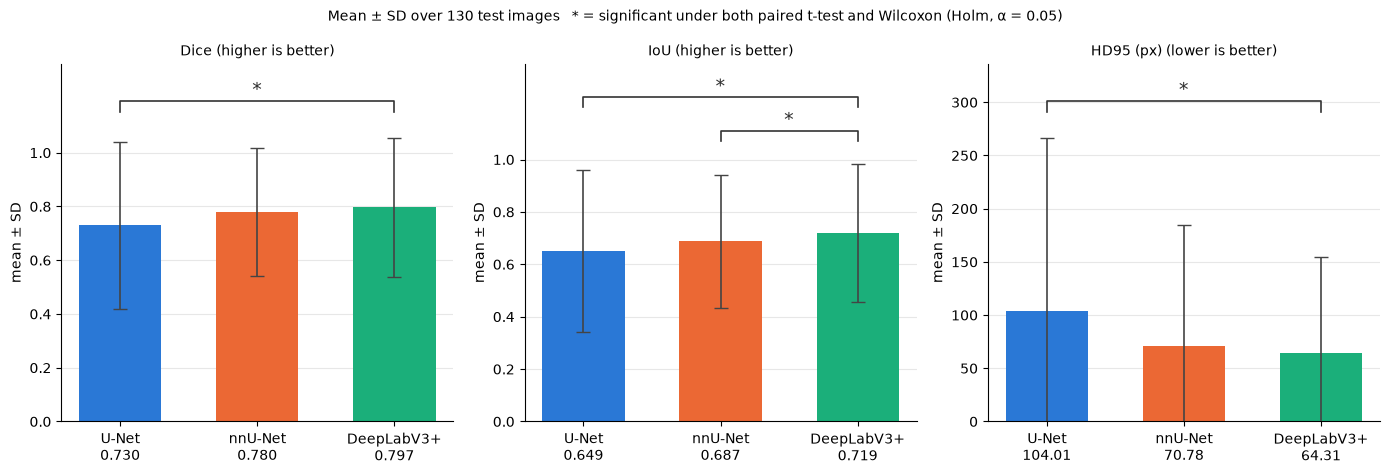

robust significant comparisons:
   metric            comparison better (mean)  p_ttest_holm  p_wilcoxon_holm
     Dice   U-Net vs DeepLabV3+    DeepLabV3+      0.001005         0.000099
      IoU   U-Net vs DeepLabV3+    DeepLabV3+      0.000243         0.000193
      IoU nnU-Net vs DeepLabV3+    DeepLabV3+      0.046091         0.004984
HD95 (px)   U-Net vs DeepLabV3+    DeepLabV3+      0.006949         0.001753


In [12]:
# Comparisons significant after Holm correction under BOTH tests (from the results table above)
robust = results[results.sig_ttest & results.sig_wilcoxon]
keys = list(MODELS)
labels = [MODELS[k]["label"] for k in keys]
x = np.arange(len(keys))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
for ax, m in zip(axes, METRICS):
    means = np.array([dfs[k][m].mean() for k in keys])
    sds = np.array([dfs[k][m].std(ddof=1) for k in keys])
    ax.bar(x, means, width=0.6, color=[MODELS[k]["color"] for k in keys], edgecolor="none", zorder=2)
    ax.errorbar(x, means, yerr=sds, fmt="none", ecolor="#444444", elinewidth=1.2, capsize=5, zorder=3)
    # Mean value under each model name, so the numbers do not collide with the error bars
    fmt = "{:.2f}" if m == "hd95" else "{:.3f}"
    ax.set_xticks(x, [f"{lab}\n{fmt.format(mu)}" for lab, mu in zip(labels, means)])

    # Significance brackets, stacked above the tallest error bar
    top = (means + sds).max()
    step = 0.13 * top
    pairs = robust[robust.metric == METRIC_LABELS[m]]
    spans = sorted((abs(labels.index(b) - labels.index(a)), labels.index(a), labels.index(b))
                   for a, b in (comp.split(" vs ") for comp in pairs.comparison))
    for level, (_, i, j) in enumerate(spans, start=1):   # shortest bracket lowest, so stars never touch a line
        y = top + step * level
        ax.plot([i, i, j, j], [y - step * 0.3, y, y, y - step * 0.3], color="#333333", linewidth=1.2)
        ax.text((i + j) / 2, y, "*", ha="center", va="bottom", fontsize=14, color="#333333")
    ax.set_ylim(0, top + step * (len(pairs) + 1))
    if m != "hd95":
        ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_title(METRIC_LABELS[m] + (" (higher is better)" if HIGHER_IS_BETTER[m] else " (lower is better)"),
                 fontsize=10)
    ax.set_ylabel("mean ± SD")
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Mean ± SD over 130 test images   * = significant under both paired t-test and Wilcoxon (Holm, α = 0.05)",
             fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "mean_comparison.png"), dpi=120)
plt.show()
print("robust significant comparisons:")
print(robust[["metric", "comparison", "better (mean)", "p_ttest_holm", "p_wilcoxon_holm"]].to_string(index=False))